## 1. Load and Inspect Dataset

In this section, the dataset is loaded using pandas and basic inspection is performed. 
This includes viewing the first few rows, checking data types, and analysing basic statistics 
to understand the structure and quality of the dataset before further processing.

In [20]:
# Load and Inspect Dataset
import pandas as pd

# Import function to split dataset into training and testing sets
from sklearn.model_selection import train_test_split
# Import scaler to normalize feature values between 0 and 1
from sklearn.preprocessing import MinMaxScaler

# Import Naive Bayes model
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import seaborn as sns
import matplotlib.pyplot as plt

# Import Logistic Regression model
from sklearn.linear_model import LogisticRegression


# Load dataset
df = pd.read_excel("NOR22597897_CleanedDataset_v2.xlsx")

# Display first few rows
df.head()

# Check structure and data types
df.info()

# Basic statistics for numerical columns
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Pass
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659,0.245951
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456,0.430682
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000,0.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000,0.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000,0.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000,0.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000,1.000000


<Axes: >

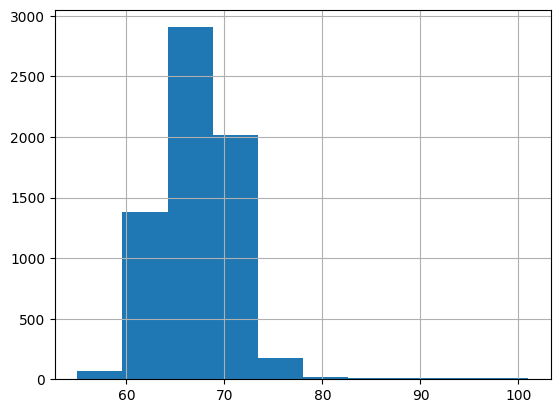

In [21]:
df["Exam_Score"].describe()
df["Exam_Score"].hist()

In [22]:
# change treshhold for passing scores 
df["Pass"] = (df["Exam_Score"] >= 70).astype(int)

# update the dataset
df.to_excel("NOR22597897_CleanedDataset_v2.xlsx", index=False)

# Check distribution

df["Pass"].value_counts()

Pass
0    4982
1    1625
Name: count, dtype: int64

In [23]:
# check the columsn
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score', 'Pass'],
      dtype='str')

In [24]:
X = df.drop(columns=["Pass", "Exam_Score"])
y = df["Pass"]

In [25]:
# Split the data:
# 80% for training the model
# 20% for testing the model
# random_state ensures we get the same split every time (reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [26]:
# Convert categorical features into numerical format using one-hot encoding
# This is required because machine learning models cannot handle text directly
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# Ensure both training and testing sets have the same columns
# If a category exists in one but not the other, we fill missing columns with 0
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [27]:
# Create scaler object
scaler = MinMaxScaler()

# Fit the scaler on training data and transform it
# (learns min/max from training data)
X_train = scaler.fit_transform(X_train)

# Apply hte same transformation to test data
# (important: DO NOT fit again on test data)
X_test = scaler.transform(X_test)

In [28]:
# Create model instance
model = GaussianNB()

# Train the model using training data
model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [29]:
# Predict outcomes on test data
y_pred = model.predict(X_test)

In [30]:
# Calculate accuracy (how many predictions were correct)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion matrix shows detailed prediction results
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# report (precision, recall, F1-score)
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8812405446293494
Confusion Matrix:
 [[890  84]
 [ 73 275]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.91      0.92       974
           1       0.77      0.79      0.78       348

    accuracy                           0.88      1322
   macro avg       0.85      0.85      0.85      1322
weighted avg       0.88      0.88      0.88      1322



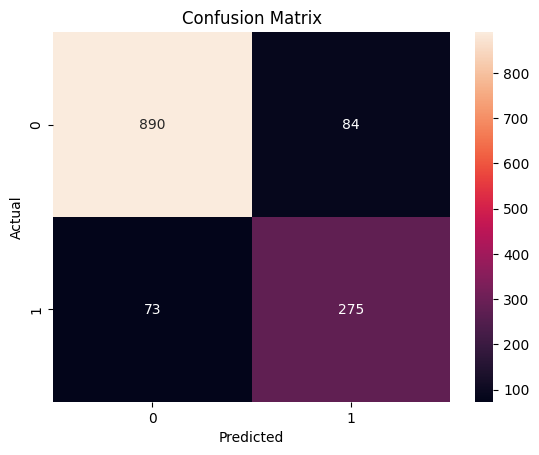

In [31]:
# Visualization
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [32]:
# Train logistic regression
# Create model instance
log_model = LogisticRegression(max_iter=1000)

# Train the model on training data
log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [33]:
# Predict outcomes on test data
y_pred_log = log_model.predict(X_test)

In [34]:
# Evaluate Logistic Regression model
log_accuracy = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", log_accuracy)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

print("Classification Report:\n", classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.9750378214826021
Confusion Matrix:
 [[969   5]
 [ 28 320]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       974
           1       0.98      0.92      0.95       348

    accuracy                           0.98      1322
   macro avg       0.98      0.96      0.97      1322
weighted avg       0.98      0.98      0.97      1322



In [ ]:
# Get feature importance (coefficients)
feature_names = X.columns  # original column names before encoding
coefficients = log_model.coef_[0]

# Create dataframe to view importance
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients[:len(feature_names)]
})

# Sort by importance
feature_importance = feature_importance.sort_values(by="Coefficient", ascending=False)

feature_importance.head(10)

,Feature,Coefficient
0,Hours_Studied,14.594916
1,Attendance,10.087211
4,Extracurricular_Activities,4.624128
3,Access_to_Resources,3.129239
5,Sleep_Hours,1.579006
9,Tutoring_Sessions,1.364422
6,Previous_Scores,1.219936
14,Physical_Activity,0.729943
18,Gender,0.696960
13,Peer_Influence,0.346160


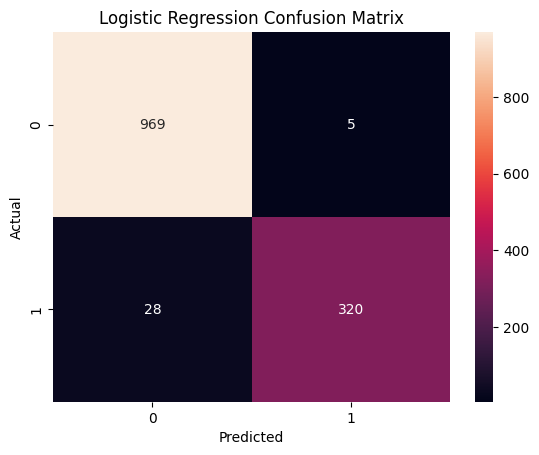

In [36]:
# Visualization for Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm_log, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
# !pip install scikit-learn
# !pip install seaborn